## MINI PROJECT:3  RETAIL SALES DASHBOARD

## The Scenario:You have just been hired as a data Anaylst for "GlobalMart" agrowing retail chain.The Regional Director has handed you a raw dataset containing months of trasaction records. she has a cirtical meeting in two hours and needs to know:   

## 📂 Step 1: Import Libraries
## Import all the required Python libraries for data analysis and visualization.

In [ ]:
# ==========================================
# DAY 27: RETAIL SALES DASHBOARD 
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## 📄 Step 2: Load Dataset
## Load the supermarket_sales.csv dataset into a Pandas DataFrame.

In [ ]:
# ---------------------------------------------------------
# SETUP: Load our "GlobalMart" Dataset
# ---------------------------------------------------------

df = pd.read_csv("supermarket_sales.csv")

print("===== HEAD =====")
print(df.head())

## 🔍 Phase 1: Data Reconnaissance & Cleaning
## Check missing values, clean the data, create new columns and prepare the dataset for analysis.

In [ ]:
# TODO 1: Check the DataFrame for missing values. Which column has NaNs?
# Write your code below:

print("\n===== Missing Values =====")
print(df.isnull().sum())

# TODO 2: Fill missing values in 'Unit price' with median price
df["Unit price"] = df["Unit price"].fillna(df["Unit price"].median())

# TODO 3: Create a new column called 'Total'.
# This should be the 'Unit price' multiplied by the 'Quantity'.
# Write your code below:

df["Total"] = df["Unit price"] * df["Quantity"]

# TODO 4: Convert the 'Date' column to a proper Pandas datetime object.
# Write your code below:

df["Date"] = pd.to_datetime(df["Date"])


## 📊 Phase 2: Grouping & Aggregation
## Group the data to calculate daily revenue and product line revenue using GroupBy and aggregation functions.

In [ ]:
# TODO 5: Create a new DataFrame called 'daily_revenue'.
# Group the main 'df' by 'Date' and calculate the SUM of the 'Total' column.
# Hint: Don't forget to use .reset_index() so it remains a clean DataFrame!
# Write your code below:
daily_revenue = df.groupby("Date")["Total"].sum().reset_index()
print("\n===== Daily Revenue =====")
print(daily_revenue.head())

# TODO 6: Create a new DataFrame called 'product_revenue'.
# Group the main 'df' by 'Product line' and calculate the SUM of the 'Total' column.
# Sort this DataFrame from highest revenue to lowest.
# Write your code below
product_revenue = (
    df.groupby("Product line")["Total"]
      .sum()
      .reset_index()
      .sort_values(by="Total", ascending=False)
)
print("\n===== Product Revenue =====")
print(product_revenue)

## 📈 Phase 3: Dashboard Visualization
## Create a 2×2 dashboard using Matplotlib and Seaborn to visualize sales trends and business insights.

In [ ]:
# We have set up the 2x2 grid (canvas) for you!

sns.set_theme(style="darkgrid")

fig, axes = plt.subplots(2, 2, figsize=(15,10))
fig.suptitle("GlobalMart Q1 Performance Dashboard",
             fontsize=20,
             fontweight="bold"
)

## 📉 Line Chart
## Shows the daily revenue trend over time.

## 📊 Bar Chart
## Compares total revenue generated by each product line.

## 📦 Box Plot
## Shows the distribution of total transaction amounts across different branches.

## 🔵 Scatter Plot
## Shows the relationship between Unit Price and Customer Rating, with different colors for each branch.

===== HEAD =====
    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   

             Product line  Unit price  Quantity   Tax 5%     Total       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

    Time      Payment    cogs  gross margin percentage  gross income  Rating  
0  13:08      Ewallet  522.83                 4.761905       26.1415

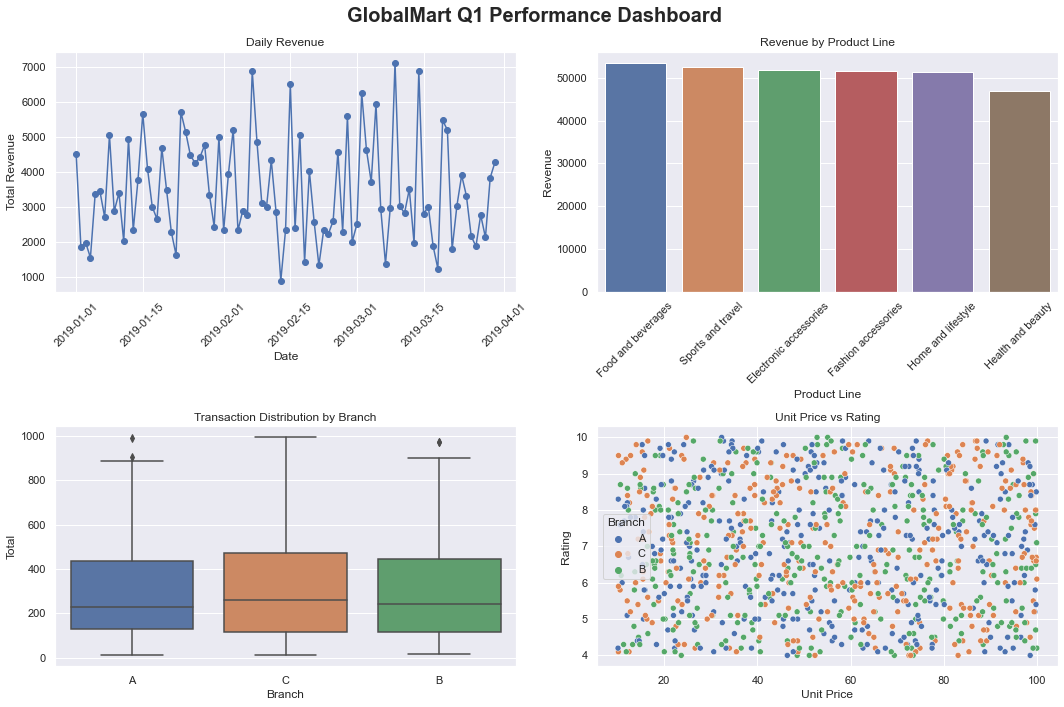

In [2]:
# --- TOP LEFT: Trend over Time (Matplotlib) ---
# TODO 7: Create a Matplotlib LINE CHART showing 'Date' vs 'Total' using your 'daily_revenue' DataFrame.
# Plot it on axes[0, 0]. Add a title and labels.


axes[0,0].plot(
    daily_revenue["Date"],
    daily_revenue["Total"],
    marker="o"
)
axes[0,0].set_title("Daily Revenue")
axes[0,0].set_xlabel("Date")
axes[0,0].set_ylabel("Total Revenue")
axes[0,0].tick_params(axis="x", rotation=45)

# --- TOP RIGHT: The Heavy Hitters (Seaborn) ---
# TODO 8: Create a Seaborn BAR CHART comparing 'Product line' and 'Total' using your 'product_revenue' DataFrame.
# Plot it on axes[0, 1]. Add a title and labels.

sns.barplot(
    data=product_revenue,
    x="Product line",
    y="Total",
    ax=axes[0,1]
)
axes[0,1].set_title("Revenue by Product Line")
axes[0,1].set_xlabel("Product Line")
axes[0,1].set_ylabel("Revenue")
axes[0,1].tick_params(axis="x", rotation=45)

# --- BOTTOM LEFT: The Distribution (Seaborn) ---
# TODO 9: Create a Seaborn BOXPLOT showing the spread of 'Total' transactions across each 'Branch'.
# Use the main 'df'. Plot it on axes[1, 0]. Add a title and labels.

sns.boxplot(
    data=df,
    x="Branch",
    y="Total",
    ax=axes[1,0]
)
axes[1,0].set_title("Transaction Distribution by Branch")
axes[1,0].set_xlabel("Branch")
axes[1,0].set_ylabel("Total")

# --- BOTTOM RIGHT: The Relationship (Seaborn) ---
# TODO 10: Create a Seaborn SCATTER PLOT comparing 'Unit price' (x) and 'Rating' (y).
# Color the dots by 'Branch' (hue). Use the main 'df'. Plot it on axes[1, 1].
# Add a title and labels.

sns.scatterplot(
    data=df,
    x="Unit price",
    y="Rating",
    hue="Branch",
    ax=axes[1,1]
)
axes[1,1].set_title("Unit Price vs Rating")
axes[1,1].set_xlabel("Unit Price")
axes[1,1].set_ylabel("Rating")

# This prevents your charts from overlapping
plt.tight_layout()

# Render your dashboard!
plt.show()

# ✅ Conclusion
## This dashboard helps analyze sales trends, product performance, branch-wise transaction distribution, and the relationship between product price and customer ratings.